# R3Con — results

Every table and figure in the paper, rebuilt from `logs/`. *Restart & Run All* to reproduce.
Scores are the judge verdicts each run recorded; nothing is re-judged here.

In [1]:
import sys
from pathlib import Path
import pandas as pd

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())
if str(ROOT / "analysis") not in sys.path:
    sys.path.insert(0, str(ROOT / "analysis"))

from scoreboard import paths, report, meta, style, load
from IPython.display import display
pd.set_option("display.max_columns", None)

Shared defaults for both benchmark sections.

In [2]:
KEEP_MODELS = {"qwen3-5-35b-a3b", "rl-memoryagent-14b",
               "claude-sonnet-4-6", "claude-sonnet-5"}
MIN_SCORED = 30
GROUNDED_NAME = style.GROUNDED_NAME
GROUNDED_METHOD = report.DEFAULT_METHOD
GROUNDED_SR = report.DEFAULT_SR
CLAUDE_MODEL = "claude-sonnet-4-6"

Plot setup.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter, NullLocator

BENCH_COLOR = {"CorpusQA": "#2b6cb0", "Loong": "#c05621"}
BENCH_HATCH = {"CorpusQA": "///", "Loong": "\\\\\\"}

def _kdollar(v, _):
    return f"${v / 1000:g}k" if v >= 1000 else f"${v:,.0f}"

# Loong

Long-context multi-doc QA. **S** = average judge score (1–100); **Accuracy** = exact-match rate,
the fraction scoring 100. Context tiers 2–4; the 10–50K tier is excluded.

In [4]:
loong = report.add_labels(report.build().query("benchmark == 'loong'"))

loong = loong[~((loong["method"] == "readagent") & (loong["config"].str.contains("lookup_method=parallel", na=False)))]

loong = loong[loong["set"] != 1]

h = report.headline(loong[loong["model"].isin(KEEP_MODELS)])
keep = h.loc[h["n_scored"] >= MIN_SCORED, report.RUN_KEY]
loong_real = loong.merge(keep, on=report.RUN_KEY)
print(f"{len(h)} runs on the kept models; {len(keep)} with >= {MIN_SCORED} graded tasks")

22 runs on the kept models; 22 with >= 30 graded tasks


In [5]:
assert 1 not in loong["set"].values and 1 not in loong_real["set"].values, "set 1 leaked into a Loong frame"
print("context tiers kept:", sorted(int(s) for s in loong_real["set"].dropna().unique()))
assert set(loong_real["model"]) <= KEEP_MODELS, f"non-kept model in loong_real: {set(loong_real['model']) - KEEP_MODELS}"
assert set(loong_real.loc[loong_real["source"] == "method", "model"]) == {report.PRIMARY_MODEL}, "our method must be 35B-only"

context tiers kept: [2, 3, 4]


In [6]:

def _band(v, lo=40, hi=65):
    if pd.isna(v):
        return ""
    c = "#1a7f37" if v >= hi else "#9a6700" if v >= lo else "#cf222e"
    return f"color: {c}; font-weight: 600"

def _band_em(v):
    return _band(v, lo=0.2, hi=0.4)

def show_board(board):
    """A `report.crosstab` board: accuracy per reasoning category, shown as a percentage."""
    return board.style.map(_band_em).format("{:.2%}", na_rep="–")

## Main results

Each method on its default configuration, all on the same served `Qwen3.5-35B-A3B`.

In [7]:
def pin_main(d):
    return d[
        ((d["source"] == "baseline") & (~d["method"].isin(["claude-code", "direct-llm"])) & (d["variant"] == "default"))
        | ((d["method"] == GROUNDED_METHOD) & (d["variant"] == "default") & (d["summary_rounds"] == GROUNDED_SR))
    ]

main = pin_main(loong_real)

aliases = {}
for _meth, _name in [(GROUNDED_METHOD, GROUNDED_NAME), ("claude-code", "Claude Code")]:
    _runs = main.loc[main["method"] == _meth, "run"]
    if len(_runs):
        aliases[_runs.iloc[0]] = _name

def alias_board(ct):
    return ct.rename(index=aliases)

print("main-results methods:", list(report.headline(main)["run"].replace(aliases)))

main-results methods: ['RAPTOR', 'ReadAgent', 'MemAgent', 'HippoRAG2', 'LinearRAG', 'StructRAG', 'CodeAgent', 'RLMs', 'A-RAG', 'R3Con']


### Accuracy by reasoning category

Every task weighted equally, so the larger tiers count for more.

In [8]:
show_board(alias_board(report.crosstab(main, col="task_name")))

,Spotlight Locating,Comparison,Chain of Reasoning,Clustering,Overall
run,,,,,
RAPTOR,51.31%,16.25%,2.04%,1.54%,12.12%
ReadAgent,60.11%,33.77%,18.49%,10.70%,24.49%
MemAgent,42.13%,35.00%,0.64%,0.95%,13.63%
HippoRAG2,46.70%,13.33%,0.33%,0.38%,10.06%
LinearRAG,32.49%,3.75%,0.64%,0.38%,6.04%
StructRAG,44.16%,30.83%,24.76%,12.19%,23.72%
CodeAgent,63.54%,45.26%,22.80%,12.90%,29.01%
RLMs,61.14%,45.15%,19.68%,15.27%,28.96%
A-RAG,35.03%,14.58%,1.28%,2.65%,9.55%


# CorpusQA

Computation-heavy QA over ~1M-token document bundles, scored 0/1. Accuracy counts every
failure — error or step-cap — as a miss. The `1m` tier; the CodeAgent baseline is its
`max_steps=60` run.

In [9]:
cq = report.add_labels(report.build_corpusqa().query("benchmark == 'corpusqa'"))

cq = cq[cq["set"] == "1m"]

cq = cq[~((cq["method"] == "codeact") & (~cq["config"].str.contains("max_steps=60", na=False)))]

h_all = report.headline(cq[cq["model"].isin(KEEP_MODELS)])
keep = h_all.loc[h_all["n_scored"] >= MIN_SCORED, report.RUN_KEY]
cq_real = cq.merge(keep, on=report.RUN_KEY)
assert set(cq_real["model"]) <= KEEP_MODELS, f"non-kept model in cq_real: {set(cq_real['model']) - KEEP_MODELS}"
assert set(cq_real.loc[cq_real["source"] == "method", "model"]) == {report.PRIMARY_MODEL}, "our method must be 35B-only"
print(f"{len(h_all)} runs on the kept models; {len(keep)} with >= {MIN_SCORED} graded tasks")
print("methods:", list(report.headline(cq_real)["run"]))

22 runs on the kept models; 20 with >= 30 graded tasks
methods: ['RAPTOR', 'ReadAgent', 'MemAgent', 'HippoRAG2', 'LinearRAG', 'StructRAG', 'CodeAgent', 'RLMs', 'A-RAG', 'Claude Code (high) [claude-sonnet-5]', 'Claude Code (high) [claude-sonnet-4-6]', 'R3Con (codeact, think, sr2)', 'R3Con (codeact, think, sr1)', 'R3Con (codeact, think, sr3)', 'R3Con (codeact, think, sr0)', 'R3Con (llm, think, sr2)', 'R3Con (llm, think, sr3)', 'R3Con (llm, think, sr1)', 'R3Con (llm, think, sr0)', 'R3Con (codeact no-parse, think, sr2)']


In [10]:

def _band_acc(v):
    if pd.isna(v):
        return ""
    c = "#1a7f37" if v >= 0.65 else "#9a6700" if v >= 0.40 else "#cf222e"
    return f"color: {c}; font-weight: 600"

## Main results

Each method on its default configuration, all on the same served `Qwen3.5-35B-A3B`.

In [11]:
def pin_main(d):
    return d[
        ((d["source"] == "baseline") & (d["method"] != "claude-code") & (d["variant"] == "default"))
        | ((d["method"] == GROUNDED_METHOD) & (d["variant"] == "default") & (d["summary_rounds"] == GROUNDED_SR))
    ]

main = pin_main(cq_real)

aliases = {}
for _meth, _name in [(GROUNDED_METHOD, GROUNDED_NAME), ("claude-code", "Claude Code")]:
    _runs = main.loc[main["method"] == _meth, "run"]
    if len(_runs):
        aliases[_runs.iloc[0]] = _name

print("main-results methods:", list(report.headline(main)["run"].replace(aliases)))

main-results methods: ['RAPTOR', 'ReadAgent', 'MemAgent', 'HippoRAG2', 'LinearRAG', 'StructRAG', 'CodeAgent', 'RLMs', 'A-RAG', 'R3Con']


### R3Con vs. Claude Code

Accuracy (with binomial standard errors) and total dollar cost: R3Con on the open
`Qwen3.5-35B-A3B` against Claude Code on two frontier models.

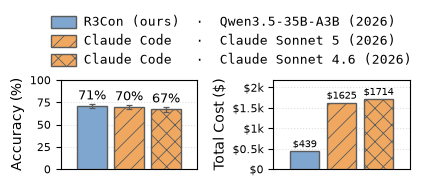

In [12]:
FIG_DIR = paths.FIGURES_DIR / "corpusqa"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DISPLAY = {"qwen3-5-35b-a3b": "Qwen3.5-35B-A3B",
                 "claude-sonnet-5": "Claude Sonnet 5", "claude-sonnet-4-6": "Claude Sonnet 4.6"}
FOCUS = [(GROUNDED_METHOD, "qwen3-5-35b-a3b", f"{GROUNDED_NAME} (ours)", ""),
         ("claude-code", "claude-sonnet-5", "Claude Code", "//"),
         ("claude-code", CLAUDE_MODEL, "Claude Code", "xx")]
bars = []
for _meth, _model, _label, _hatch in FOCUS:
    sub = cq_real[(cq_real["method"] == _meth) & (cq_real["model"] == _model)]
    if _meth == GROUNDED_METHOD:
        sub = sub[(sub["variant"] == "default") & (sub["summary_rounds"] == GROUNDED_SR)]
    _real, _allv, _, _ = report._scores(sub)
    _p, _n = _allv.mean(), len(_allv)
    bars.append({
        "label": _label, "method": _meth, "model": _model, "hatch": _hatch, "acc": _p, "n": _n,
        "se": (_p * (1 - _p) / _n) ** 0.5,
        "usd": sub.loc[sub["status"] == "ok", "usd"].sum(),
    })

import matplotlib.patches as mpatches

EDGE = "#5a5a5a"
plt.rcParams["hatch.linewidth"] = 0.6
_ERR = {"ecolor": "#5c5a5a", "elinewidth": 0.9, "capthick": 0.9}

xs = list(range(len(bars)))
colors = [style.color(b["method"]) for b in bars]
hatches = [b["hatch"] for b in bars]
fig, (axA, axC) = plt.subplots(1, 2, figsize=(4.3, 1.5))

accs = [b["acc"] * 100 for b in bars]
ses = [b["se"] * 100 for b in bars]
barsA = axA.bar(xs, accs, yerr=ses, capsize=2.5, color=colors, edgecolor=EDGE, linewidth=1.0,
                error_kw=_ERR, zorder=3)
for _rect, _h in zip(barsA, hatches):
    _rect.set_hatch(_h)
axA.set_ylabel("Accuracy (%)", fontsize=10)
axA.set_ylim(0, 100)
for x, a, s in zip(xs, accs, ses):
    axA.text(x, a + s + 1.5, f"{a:.0f}%", ha="center", va="bottom", fontsize=9.5)

_umax = max(b["usd"] for b in bars)
barsC = axC.bar(xs, [b["usd"] for b in bars], color=colors, edgecolor=EDGE, linewidth=1.0, zorder=3)
for _rect, _h in zip(barsC, hatches):
    _rect.set_hatch(_h)
axC.set_ylabel("Total Cost ($)", fontsize=10)
axC.set_ylim(0, _umax * 1.27)
axC.set_yticks([0, 500, 1000, 1500, 2000])
axC.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v / 1000:g}k" if v >= 500 else f"${v:,.0f}"))
for x, b in zip(xs, bars):
    axC.text(x, b["usd"] + _umax * 0.02, f"${b['usd']:.0f}", ha="center", va="bottom", fontsize=7.5)

for ax in (axA, axC):
    ax.set_xticks([])
    ax.set_xlim(-0.85, len(bars) - 0.15)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(True, axis="y", ls=":", alpha=0.4, zorder=0)
_lw = max(len(b["label"]) for b in bars)
handles = [mpatches.Patch(facecolor=style.color(b["method"]),
                          edgecolor=EDGE, hatch=b["hatch"],
                          label=f"{b['label']:<{_lw}}  ·  {MODEL_DISPLAY.get(b['model'], b['model'])} (2026)")
           for b in bars]
fig.tight_layout(w_pad=1.1)
fig.subplots_adjust(top=0.74)
fig.legend(handles=handles, loc="upper center", ncol=1, frameon=False,
           bbox_to_anchor=(0.55, 1.25), handlelength=2.0, handleheight=1.1,
           handletextpad=0.6, labelspacing=0.4, prop={"family": "monospace", "size": 9.0})
fig.savefig(FIG_DIR / "grounded_vs_claude.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "grounded_vs_claude.png", dpi=300, bbox_inches="tight")
display(fig)
plt.close(fig)

# Cross-benchmark

## Ablations — the two phases

The default configuration against removing one phase of the pipeline, all else equal. Cells are
exact-match (Loong) / accuracy (CorpusQA), with the change vs the default.

In [13]:
_abl = pd.DataFrame({
    "Loong":      report.ablations(loong).set_index("ablation")["em"],
    "CorpusQA":   report.ablations(cq).set_index("ablation")["em"],
})
_abl.index.name = "Ablation"


def _abl_text(v, base):
    if pd.isna(v):
        return "–"
    pct = f"{v * 100:.2f}%"
    return pct if v == base else f"{pct} ({(v - base) * 100:+.2f})"


_abl_style = pd.DataFrame("", index=_abl.index, columns=_abl.columns)
_abl_style["Loong"] = _abl["Loong"].map(_band_em)
_abl_style["CorpusQA"] = _abl["CorpusQA"].map(_band_acc)
_abl_disp = pd.DataFrame(
    {c: [_abl_text(v, _abl[c].loc["Default"]) for v in _abl[c]] for c in _abl.columns},
    index=_abl.index)
display(_abl_disp.style.apply(lambda _: _abl_style, axis=None))

,Loong,CorpusQA
Ablation,,
Default,37.43%,70.64%
w/o extracting relevance,23.96% (-13.47),52.58% (-18.06)
w/o structuring,32.97% (-4.46),63.22% (-7.42)


## Downstream reasoning

Not an ablation: both phases intact, the *same* representation handed to a different downstream
reasoner.

In [14]:
_dwn = pd.DataFrame({
    "CorpusQA": report.downstream(cq).set_index("downstream")["em"],
    "Loong":    report.downstream(loong).set_index("downstream")["em"],
})
_dwn.index.name = "Downstream reasoning"
_dwn_style = pd.DataFrame("", index=_dwn.index, columns=_dwn.columns)
_dwn_style["Loong"] = _dwn["Loong"].map(_band_em)
_dwn_style["CorpusQA"] = _dwn["CorpusQA"].map(_band_acc)
display(_dwn.style.apply(lambda _: _dwn_style, axis=None).format("{:.2%}", na_rep="–"))

for _c in _dwn.columns:
    _w = _dwn[_c].idxmax()
    print(f"  {_c:9s} best = {_w} ({_dwn[_c].max() * 100:.2f}%), "
          f"margin {(_dwn[_c].max() - _dwn[_c].min()) * 100:+.2f} pp over "
          f"{_dwn[_c].idxmin()}")

,CorpusQA,Loong
Downstream reasoning,,
LLM,65.43%,40.17%
Coding agent (default),70.64%,37.43%


  CorpusQA  best = Coding agent (default) (70.64%), margin +5.21 pp over LLM
  Loong     best = LLM (40.17%), margin +2.74 pp over Coding agent (default)


## Totals — accuracy by category

Each method's accuracy by category, same served model.

In [15]:
def _main_pin(df):
    keep = (df["source"] == "baseline") & (~df["method"].isin(["claude-code", "direct-llm"])) & (df["variant"] == "default")
    keep |= (df["method"] == GROUNDED_METHOD) & (df["variant"] == "default") & (df["summary_rounds"] == GROUNDED_SR)
    return df[keep]

_lp, _cp = _main_pin(loong_real), _main_pin(cq_real)

_CQ_DOMAINS = {"Education": "education", "Financial": "financial", "Real estate": "real estate"}
_LO_DOMAINS = {"Paper": "paper", "Financial": "financial", "Legal": "legal"}

_spec = [(("CorpusQA", _d), _cp, _dom, 0) for _d, _dom in _CQ_DOMAINS.items()]
_spec += [(("CorpusQA", "Overall"), _cp, None, 0)]
_spec += [(("Loong", _d), _lp, _dom, 1) for _d, _dom in _LO_DOMAINS.items()]
_spec += [(("Loong", "Overall"), _lp, None, 1)]
_tcols = pd.MultiIndex.from_tuples([c for c, *_ in _spec])

_methods = [m for m in style.ORDER
            if any(m in set(p["method"]) for p in (_cp, _lp))]
_tdata, _tidx = [], []
for _m in _methods:
    _row = {}
    for _col, _pin, _dom, _si in _spec:
        _g = _pin[_pin["method"] == _m]
        if _dom is not None:
            _g = _g[_g["domain"] == _dom]
        _row[_col] = report._se(_g)[_si] if len(_g) else float("nan")
    _tdata.append(_row); _tidx.append(style.name(_m))
totals = pd.DataFrame(_tdata, index=_tidx, columns=_tcols).rename_axis("method")


def _totals_style(df):
    s = pd.DataFrame("", index=df.index, columns=df.columns)
    for _col in df.columns:
        s[_col] = df[_col].map(_band_em if _col[0] == "Loong" else _band_acc)
    return s


totals.style.apply(_totals_style, axis=None).format("{:.2%}", na_rep="–")

### Overall accuracy and R3Con's margin over the best baseline

In [16]:
_ov_bench = [("CorpusQA", _cp, 0), ("Loong", _lp, 1)]

def _ov_acc(pin, m, si):
    g = pin[pin["method"] == m]
    return report._se(g)[si] if len(g) else float("nan")

print(f"Overall accuracy (⁺all) — {GROUNDED_NAME} vs. the best baseline:\n")
for _name, _pin, _si in _ov_bench:
    _ours = _ov_acc(_pin, GROUNDED_METHOD, _si)
    _others = {m: _ov_acc(_pin, m, _si) for m in _pin["method"].unique() if m != GROUNDED_METHOD}
    _others = {m: v for m, v in _others.items() if v == v}
    _bm, _bv = max(_others.items(), key=lambda kv: kv[1])
    _d = (_ours - _bv) * 100
    _verb = "gain" if _d >= 0 else "loss"
    print(f"  {_name:11s} {GROUNDED_NAME} {_ours * 100:6.2f}%   vs best baseline {style.name(_bm)} "
          f"{_bv * 100:.2f}%   -> {_verb} {abs(_d):.2f} pp")

Overall accuracy (⁺all) — R3Con vs. the best baseline:

  CorpusQA    R3Con  70.64%   vs best baseline StructRAG 50.76%   -> gain 19.88 pp
  Loong       R3Con  37.43%   vs best baseline CodeAgent 29.01%   -> gain 8.42 pp


## Total cost

Accuracy vs total dollar cost on each benchmark, log-x. The dashed line is the cost/quality
Pareto frontier — anything below it is beaten on both price and accuracy. R3Con's default also
appears on the smaller `Qwen3.5-9B` and `Qwen3.5-4B`.

In [17]:
from matplotlib.lines import Line2D

FIG_DIR = paths.FIGURES_DIR / "cross"
FIG_DIR.mkdir(parents=True, exist_ok=True)

loong_pin = loong_real[
    ((loong_real["source"] == "baseline") & (~loong_real["method"].isin(["claude-code", "direct-llm"])) & (loong_real["variant"] == "default"))
    | ((loong_real["method"] == GROUNDED_METHOD) & (loong_real["variant"] == "default") & (loong_real["summary_rounds"] == GROUNDED_SR))
]
cq_pin = cq_real[
    ((cq_real["source"] == "baseline") & (cq_real["method"] != "claude-code") & (cq_real["variant"] == "default"))
    | ((cq_real["method"] == GROUNDED_METHOD) & (cq_real["variant"] == "default") & (cq_real["summary_rounds"] == GROUNDED_SR))
]
loong_cost = report.cost_table(loong_pin)
loong_cost = loong_cost[loong_cost["usd_total"].notna()]
cq_cost = report.cost_table(cq_pin)
cq_cost = cq_cost[cq_cost["usd_total"].notna()]


_PARETO_KW = dict(ls="--", lw=1.1, color="#7a7a7a", alpha=0.75)

_Z_OURS, _Z_BASE = 2.5, 3
_MARK_S = 80
_LEG_MS = 8
_OURS_LEG_MS = 15
_OURS_SCALE = _OURS_LEG_MS / _LEG_MS


def _pareto_front(xs, ys):
    """The non-dominated (cheap, accurate) points: walking cheapest→dearest, keep every point that
    beats ALL cheaper ones on accuracy. Anything below the resulting line is dominated — some other
    method is both cheaper AND better."""
    front, best = [], float("-inf")
    for x, y in sorted(zip(xs, ys)):
        if y > best:
            front.append((x, y))
            best = y
    return front


def _cost_panel(ax, cost, col, yfn, title, xticks, xlim, show_xlabel, extra=None):
    """One cost/quality panel. ``extra`` (optional) = additional points of OUR method on other Qwen
    sizes — a frame with ``usd_total``, ``col``, ``_s`` (marker area, pt²) and ``label`` — drawn with our
    marker/colour at their own size. They join the x-limit guard, the Pareto frontier and the y-range,
    so no plotted point can sit above the frontier line. ``extra=None`` draws the panel without them."""
    _extra = extra if extra is not None else pd.DataFrame(columns=["usd_total", col, "_s", "label"])
    _out = cost[(cost["usd_total"] < xlim[0]) | (cost["usd_total"] > xlim[1])]
    _out_x = _extra[(_extra["usd_total"] < xlim[0]) | (_extra["usd_total"] > xlim[1])]
    if len(_out) or len(_out_x):
        print(f"  !! {title}: {list(_out['method']) + list(_out_x['label'])} outside x-limits {xlim} — widen them")
    _front = _pareto_front([*cost["usd_total"], *_extra["usd_total"]],
                           [*cost[col].map(yfn), *_extra[col].map(yfn)])
    if len(_front) > 1:
        ax.plot([p[0] for p in _front], [p[1] for p in _front], zorder=2, **_PARETO_KW)
    for _, r in _extra.iterrows():
        ax.scatter(r["usd_total"], yfn(r[col]), s=r["_s"], edgecolor="black", linewidth=0.4,
                   color=style.GROUNDED_COLOR, marker=style.marker(GROUNDED_METHOD), zorder=_Z_OURS)
    for _, r in cost.iterrows():
        _is_ours = r["method"].startswith("grounded")
        ax.scatter(r["usd_total"], yfn(r[col]),
                   s=_MARK_S * (_OURS_SCALE ** 2 if _is_ours else 1),
                   edgecolor="black", linewidth=0.4,
                   color=style.color(r["method"]), marker=style.marker(r["method"]),
                   zorder=_Z_OURS if _is_ours else _Z_BASE)
    ys = cost[col].map(yfn)
    if len(_extra):
        ys = pd.concat([ys, _extra[col].astype(float).map(yfn)], ignore_index=True)
    ax.set_xscale("log")
    ax.set_xlim(*xlim)
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(FuncFormatter(_kdollar))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_ylim(max(0, ys.min() - 10), ys.max() + 13.5)
    ax.set_title(title, fontsize=11)
    if show_xlabel:
        ax.set_xlabel("Total Cost ($)", fontsize=11)
    ax.tick_params(labelsize=9.5)
    ax.grid(True, which="major", ls=":", alpha=0.4)


present = set(loong_cost["method"]) | set(cq_cost["method"])
order = [m for m in style.ORDER if m in present]


def _handle(m, size=_LEG_MS):
    return Line2D([], [], marker=style.marker(m), markerfacecolor=style.color(m), markeredgecolor="black",
                  markeredgewidth=0.4, markersize=size, linestyle="None")


_base = [m for m in order if not m.startswith("grounded")]

Loong     R3Con (9B)     acc= 33.54%  total=$87.30
Loong     R3Con (4B)     acc= 30.23%  total=$42.76
CorpusQA  R3Con (9B)     acc= 54.88%  total=$173.90
CorpusQA  R3Con (4B)     acc= 49.24%  total=$81.94


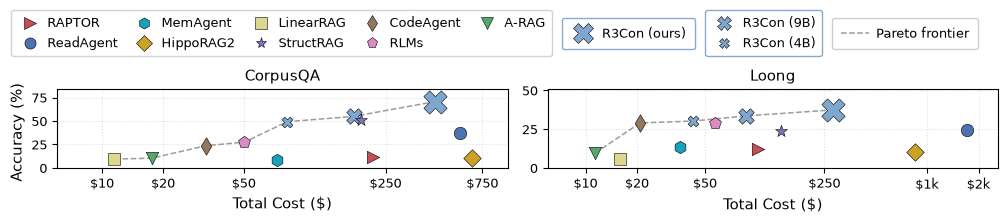

In [18]:
_SIZES = [("qwen3-5-9b", f"{GROUNDED_NAME} (9B)", 10), ("qwen3-5-4b", f"{GROUNDED_NAME} (4B)", 7)]

def _size_points(df, col):
    """Our default config on each smaller size, as `_cost_panel` `extra` points. `df` is the section's
    scoped per-inference frame (`loong` / `cq`) — NOT `*_real`, which KEEP_MODELS has stripped of these."""
    rows = []
    for model, label, pt in _SIZES:
        g = df[(df["source"] == "method") & (df["method"] == GROUNDED_METHOD) & (df["variant"] == "default")
               & (df["summary_rounds"] == GROUNDED_SR) & (df["model"] == model)]
        c = report.cost_table(g).iloc[0]
        rows.append({"usd_total": c["usd_total"], col: c[col], "label": label,
                     "_s": _MARK_S * (pt / _LEG_MS) ** 2})
    return pd.DataFrame(rows)


loong_sizes = _size_points(loong, "EM")
cq_sizes = _size_points(cq, "S")
for _b, _t, _col in (("Loong", loong_sizes, "EM"), ("CorpusQA", cq_sizes, "S")):
    for _, r in _t.iterrows():
        print(f"{_b:9s} {r['label']:14s} acc={100 * r[_col]:6.2f}%  total=${r['usd_total']:,.2f}")

fig, (axC, axL) = plt.subplots(1, 2, figsize=(10.45, 1.74))
_cost_panel(axL, loong_cost, "EM", lambda s: s * 100, "Loong",    [10, 20, 50, 250, 1000, 2000], (6, 2600), show_xlabel=True, extra=loong_sizes)
_cost_panel(axC, cq_cost,    "S",  lambda s: s * 100, "CorpusQA", [10, 20, 50, 250, 750],        (6, 1000), show_xlabel=True, extra=cq_sizes)
fig.supylabel("Accuracy (%)", fontsize=11, x=0.04, y=0.55)
axL.set_yticks([0, 25, 50])
axC.set_yticks([0, 25, 50, 75])

fig.tight_layout()
fig.subplots_adjust(left=0.085)
_LEG_GAP = 0.004
_rend = fig.canvas.get_renderer()
_right = lambda leg: leg.get_window_extent(_rend).transformed(fig.transFigure.inverted()).x1
_lb = fig.legend([_handle(m) for m in _base], [style.name(m) for m in _base],
                 loc="lower left", bbox_to_anchor=(0.035, 0.95), ncol=5, fontsize=9,
                 frameon=True, framealpha=0.9, handletextpad=0.4, columnspacing=1.1,
                 labelspacing=0.5, borderpad=0.5)
_lo = fig.legend([_handle(GROUNDED_METHOD, size=_LEG_MS * _OURS_SCALE)], [f"{GROUNDED_NAME} (ours)"],
                 loc="lower left", bbox_to_anchor=(_right(_lb) + _LEG_GAP, 0.99), ncol=1, fontsize=9,
                 frameon=True, framealpha=0.95, handletextpad=0.5, borderpad=0.7, edgecolor=style.GROUNDED_COLOR)
_ls = fig.legend([_handle(GROUNDED_METHOD, size=pt) for _, _, pt in _SIZES], [lbl for _, lbl, _ in _SIZES],
                 loc="lower left", bbox_to_anchor=(_right(_lo) + _LEG_GAP, 0.95), ncol=1, fontsize=9,
                 frameon=True, framealpha=0.95, handletextpad=0.5, labelspacing=0.5, borderpad=0.5,
                 edgecolor=style.GROUNDED_COLOR)
fig.legend([Line2D([], [], **_PARETO_KW)], ["Pareto frontier"],
           loc="lower left", bbox_to_anchor=(_right(_ls) + _LEG_GAP, 0.99), ncol=1, fontsize=9,
           frameon=True, framealpha=0.95, handletextpad=0.6, borderpad=0.7, handlelength=2.2)
fig.savefig(FIG_DIR / "cost_cross_sizes.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "cost_cross_sizes.png", dpi=300, bbox_inches="tight")
display(fig)
plt.close(fig)

## Model sizes

R3Con against the two strongest baselines with the whole pipeline on one model size.

In [19]:
_SIZE_MODELS = [("qwen3-5-35b-a3b", "Qwen3.5-35B-A3B"), ("qwen3-5-9b", "Qwen3.5-9B"),
                ("qwen3-5-4b", "Qwen3.5-4B")]
_SIZE_METHODS = ["structrag", "codeact", GROUNDED_METHOD]
_SIZE_BENCH = [("CorpusQA", cq, "S"), ("Loong", loong, "EM")]


def _size_acc(model, meth, df, col):
    g = df[(df["method"] == meth) & (df["model"] == model) & (df["variant"] == "default")]
    if meth == GROUNDED_METHOD:
        g = g[g["summary_rounds"] == GROUNDED_SR]
    return report.cost_table(g).iloc[0][col] if len(g) else float("nan")


sizes = pd.DataFrame(
    [{b: _size_acc(_model, _m, df, col) for b, df, col in _SIZE_BENCH}
     for _model, _ in _SIZE_MODELS for _m in _SIZE_METHODS],
    index=pd.MultiIndex.from_tuples([(_label, style.name(_m))
                                     for _, _label in _SIZE_MODELS for _m in _SIZE_METHODS]),
).rename_axis(["model", "method"])


def _best_per_model(df):
    out = pd.DataFrame("", index=df.index, columns=df.columns)
    for _model in df.index.get_level_values(0).unique():
        for c in df.columns:
            blk = df.loc[_model, c]
            if blk.notna().any():
                out.loc[(_model, blk.idxmax()), c] = "font-weight: 700"
    return out


sizes.style.apply(_best_per_model, axis=None).format("{:.2%}", na_rep="–")

# Method internals

How big R3Con's intermediate representation is next to the documents it replaces, on the default
configuration. Every count is exact tokens from the served model's own tokenizer.

In [20]:
art = load.load_method_artifacts()
art = art[(art["variant"] == "default") & (art["summary_rounds"] == GROUNDED_SR)
          & (art["model"] == report.PRIMARY_MODEL)].copy()

_lm, _cm = meta.loong_meta(), meta.corpusqa_meta()
art["set"] = [(_lm.get(t, {}).get("set") if b == "loong" else _cm.get(t, {}).get("set"))
              for b, t in zip(art["benchmark"], art["task_id"])]
art["task"] = art["task_id"].astype("string").str.extract(r"@(task\d+)$", expand=False)
art = art[((art["benchmark"] == "loong") & (art["set"] != 1))
          | ((art["benchmark"] == "corpusqa") & (art["set"] == "1m"))]


art["input_tokens"] = [float((_lm if b == "loong" else _cm)[t]["input_tokens"])
                       for b, t in zip(art["benchmark"], art["task_id"])]
print("runs (default config):", art.groupby("benchmark").size().to_dict())

runs (default config): {'corpusqa': 329, 'loong': 1277}


### Compression per benchmark

In [21]:
_BENCH_ORDER = ["loong", "corpusqa"]
_BENCH_LABEL = {"loong": "Loong", "corpusqa": "CorpusQA"}

_rows, _idx = [], []
for _b in [b for b in _BENCH_ORDER if b in set(art["benchmark"])]:
    _g = art[art["benchmark"] == _b]
    _in = _g["input_tokens"].mean()
    _row = {("", "n"): len(_g), ("Input", "tokens"): _in}
    for _label, _col in [("Summaries", "summary_tokens"), ("Parse", "parse_tokens")]:
        _a = _g[_col].mean()
        _row[(_label, "tokens")] = _a
        _row[(_label, "% of input")] = _a / _in if _in else float("nan")
        _row[(_label, "compression")] = _in / _a if _a else float("nan")
        _row[(_label, "median ×")] = (_g["input_tokens"] / _g[_col].replace(0, float("nan"))).median()
    _row[("Schema", "tokens")] = _g["schema_tokens"].mean()
    _rows.append(_row); _idx.append(_BENCH_LABEL[_b])
compress = pd.DataFrame(_rows, index=_idx).rename_axis("benchmark")

_fmt = {c: ("{:,.0f}" if c[1] in ("tokens", "n") else ("{:.2%}" if c[1] == "% of input" else "{:.1f}×"))
        for c in compress.columns}
compress.style.format(_fmt, na_rep="–").map(
    lambda v: "color: #1a7f37; font-weight: 600",
    subset=[c for c in compress.columns if c[1] in ("compression", "median ×")])

,"('', 'n')","('Input', 'tokens')","('Summaries', 'tokens')","('Summaries', '% of input')","('Summaries', 'compression')","('Summaries', 'median ×')","('Parse', 'tokens')","('Parse', '% of input')","('Parse', 'compression')","('Parse', 'median ×')","('Schema', 'tokens')"
benchmark,,,,,,,,,,,
Loong,"1,277","103,541","1,344",1.30%,77.0×,101.0×,766,0.74%,135.2×,277.5×,175
CorpusQA,329,"899,942","7,454",0.83%,120.7×,147.0×,"8,410",0.93%,107.0×,293.3×,198


### Representation size

Average per task: the external context, the relevant context 𝓡, and the structured data.

In [22]:
_PAPER_BENCH = [("corpusqa", "CorpusQA"), ("loong", "Loong")]
_PAPER_ROWS = [
    ("External context", None),
    ("Relevant context 𝓡", "summary_tokens"),
    ("Structured data", "parse_tokens"),
]
_avg = {b: art.loc[art["benchmark"] == b, ["input_tokens", "summary_tokens", "parse_tokens"]].mean()
        for b, _ in _PAPER_BENCH}
ir_size = pd.DataFrame(
    {(lbl, k): [(_avg[b]["input_tokens"] if col is None else _avg[b][col]) if k == "avg tokens"
                else (1.0 if col is None else _avg[b][col] / _avg[b]["input_tokens"]) for _, col in _PAPER_ROWS]
     for b, lbl in _PAPER_BENCH for k in ("avg tokens", "% of context")},
    index=[name for name, _ in _PAPER_ROWS]).rename_axis("representation")
ir_size.style.format({c: ("{:,.0f}" if c[1] == "avg tokens" else "{:.2%}") for c in ir_size.columns})

### Token distributions, per example

The spread behind those averages. One shared log token axis; dashed lines are medians.

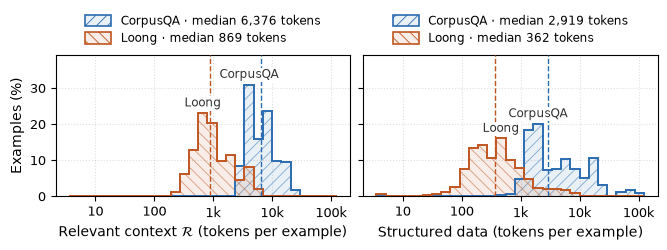

In [23]:
FIG_DIR = paths.FIGURES_DIR / "cross"
FIG_DIR.mkdir(parents=True, exist_ok=True)

_IR_BENCH = [("CorpusQA", "corpusqa"), ("Loong", "loong")]
_IR_PANELS = [(r"Relevant context $\mathcal{R}$ (tokens per example)", "summary_tokens"),
              ("Structured data (tokens per example)", "parse_tokens")]
_IR_INK = "#333333"

_vals = {(b, col): art.loc[(art["benchmark"] == b) & (art[col] > 0), col] for _, b in _IR_BENCH for _, col in _IR_PANELS}
_lo = min(v.min() for v in _vals.values()); _hi = max(v.max() for v in _vals.values())
_ir_bins = np.logspace(np.log10(_lo) - 0.05, np.log10(_hi) + 0.05, 30)

from matplotlib.colors import to_rgba
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.6), sharex=True, sharey=True)
for ax, (xlabel, col) in zip(axes, _IR_PANELS):
    handles = []
    for label, b in _IR_BENCH:
        v, color, hatch = _vals[(b, col)], BENCH_COLOR[label], BENCH_HATCH[label]
        w = np.full(len(v), 100 / len(v))
        ax.hist(v, bins=_ir_bins, weights=w, histtype="stepfilled", facecolor=to_rgba(color, 0.10),
                edgecolor=to_rgba(color, 0.55), hatch=hatch, lw=0, zorder=2)
        h, _, _ = ax.hist(v, bins=_ir_bins, weights=w, histtype="step", color=color, lw=1.4, zorder=3)
        ax.axvline(v.median(), color=color, ls="--", lw=1.0, zorder=4)
        handles.append(Patch(facecolor=to_rgba(color, 0.10), edgecolor=color, hatch=hatch, lw=1.2,
                             label=f"{label} · median {v.median():,.0f} tokens"))
        pk = int(np.argmax(h))
        ax.text(np.sqrt(_ir_bins[pk] * _ir_bins[pk + 1]), h[pk] + 1.0, label, ha="center", va="bottom",
                fontsize=8.5, color=_IR_INK, zorder=5, bbox=dict(facecolor="white", edgecolor="none", pad=0.8))
    ax.set_xscale("log")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(True, ls=":", alpha=0.4, zorder=0)
    ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=1, fontsize=8.5,
              frameon=False, handlelength=2.2, handleheight=1.1, labelspacing=0.35)
axes[0].set_ylabel("Examples (%)", fontsize=10)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:g}k" if v >= 1000 else f"{v:g}"))
axes[0].xaxis.set_minor_locator(NullLocator())
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
fig.tight_layout(w_pad=0.4)
fig.savefig(FIG_DIR / "ir_tokens.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "ir_tokens.png", dpi=300, bbox_inches="tight")
display(fig)
plt.close(fig)

display(pd.DataFrame([{"benchmark": label, "component": "R" if col == "summary_tokens" else "structured",
                       "examples": len(_vals[(b, col)]), "p10": _vals[(b, col)].quantile(.1),
                       "median": _vals[(b, col)].median(), "mean": _vals[(b, col)].mean(),
                       "p90": _vals[(b, col)].quantile(.9), "max": _vals[(b, col)].max()}
                      for label, b in _IR_BENCH for _, col in _IR_PANELS]).set_index(["benchmark", "component"])
        .style.format({k: "{:,.0f}" for k in ("p10", "median", "mean", "p90", "max")}))

### Per-task compression

In [24]:
_dist_rows, _dist_idx = [], []
for _b in [b for b in _BENCH_ORDER if b in set(art["benchmark"])]:
    _g = art[art["benchmark"] == _b]
    for _label, _col in [("Summaries", "summary_tokens"), ("Parse", "parse_tokens")]:
        _r = (_g["input_tokens"] / _g[_col].replace(0, float("nan"))).dropna()
        _dist_rows.append({"p10": _r.quantile(.10), "median": _r.median(),
                           "p90": _r.quantile(.90), "max": _r.max()})
        _dist_idx.append((_BENCH_LABEL[_b], _label))
dist = pd.DataFrame(_dist_rows, index=pd.MultiIndex.from_tuples(_dist_idx)).rename_axis(["benchmark", "artifact"])
dist.style.format("{:.1f}×", na_rep="–")

# Summary rounds (N)

Sweeping `summary_rounds` from 0 to 3. N = 0 is the no-relevance ablation; the dashed line is the
pinned default N = 2.

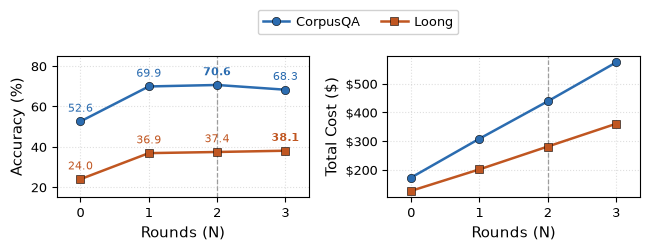

In [25]:
FIG_DIR = paths.FIGURES_DIR / "cross"
FIG_DIR.mkdir(parents=True, exist_ok=True)

_SR_BENCH = [("CorpusQA", cq_real, 0), ("Loong", loong_real, 1)]
_SR_STYLE = {"CorpusQA": (BENCH_COLOR["CorpusQA"], "o"), "Loong": (BENCH_COLOR["Loong"], "s")}
_SR_VALUES = [0, 1, 2, 3]

_sr_data = {}
for _name, _df, _si in _SR_BENCH:
    _acc, _usd, _ns = [], [], []
    for _sr in _SR_VALUES:
        _g = _df[(_df["source"] == "method") & (_df["method"] == GROUNDED_METHOD)
                 & (_df["variant"] == "default") & (_df["summary_rounds"] == _sr)
                 & (_df["model"] == report.PRIMARY_MODEL)]
        _acc.append(report._se(_g)[_si] * 100 if len(_g) else float("nan"))
        _usd.append(_g.loc[_g["status"] == "ok", "usd"].sum() if len(_g) else float("nan"))
        _ns.append(len(_g))
    _sr_data[_name] = {"acc": _acc, "usd": _usd, "n": _ns}

sr_table = pd.DataFrame(
    {(_name, lbl): _sr_data[_name][key] for _name, _, _ in _SR_BENCH
     for lbl, key in (("Accuracy %", "acc"), ("Total $", "usd"), ("tasks", "n"))},
    index=pd.Index(_SR_VALUES, name="N"))
display(sr_table.style.format({c: ("{:,.0f}" if c[1] == "tasks" else "{:,.2f}")
                               for c in sr_table.columns}))

fig, (axA, axC) = plt.subplots(1, 2, figsize=(6.6, 2.15))
for _ax, _key, _ylab in [(axA, "acc", "Accuracy (%)"), (axC, "usd", "Total Cost ($)")]:
    for _name, _, _ in _SR_BENCH:
        _c, _mk = _SR_STYLE[_name]
        _ax.plot(_SR_VALUES, _sr_data[_name][_key], marker=_mk, color=_c, markeredgecolor="black",
                 markeredgewidth=0.4, markersize=6, linewidth=1.8, label=_name, zorder=3)
    _ax.axvline(GROUNDED_SR, color="#9a9a9a", ls="--", lw=0.9, zorder=1)
    _ax.set_xlabel("Rounds (N)", fontsize=11)
    _ax.set_ylabel(_ylab, fontsize=11)
    _ax.set_xticks(_SR_VALUES)
    _ax.set_xlim(-0.35, 3.35)
    _ax.tick_params(labelsize=9.5)
    _ax.grid(True, ls=":", alpha=0.4, zorder=0)
for _name, _, _ in _SR_BENCH:
    _c, _ = _SR_STYLE[_name]
    _vals = _sr_data[_name]["acc"]
    _best = max(range(len(_vals)), key=lambda i: _vals[i])
    for _i, _v in enumerate(_vals):
        axA.annotate(f"{_v:.1f}", (_SR_VALUES[_i], _v), textcoords="offset points", xytext=(0, 7),
                     ha="center", fontsize=8, color=_c,
                     fontweight="bold" if _i == _best else "normal", zorder=4)
axA.set_yticks([20, 40, 60, 80])
axA.set_ylim(15, 85)
axC.yaxis.set_major_formatter(FuncFormatter(_kdollar))

fig.tight_layout()
fig.legend(*axA.get_legend_handles_labels(), loc="lower center", bbox_to_anchor=(0.55, 1.0),
           ncol=2, fontsize=9.5, frameon=True, framealpha=0.9, handletextpad=0.5, columnspacing=1.6)
fig.savefig(FIG_DIR / "summary_rounds.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "summary_rounds.png", dpi=300, bbox_inches="tight")
display(fig)
plt.close(fig)